# Python GIS Procedural Pipeline

This notebook implements an end-to-end pipeline:
1. Draw a polygon on an interactive map
2. Extract GeoJSON & transform coordinates to UTM (CCW ordering)
3. Generate a procedural building with PyPRT (CityEngine)
4. Visualize the 3D model with Autodesk Viewer

## تثبيت المكتبات (Install Libraries)

If running outside the project venv, uncomment the following line:
```
# !pip install leafmap shapely pyproj pyprt pythreejs ipywidgets trimesh
```

---
## الخلية 1: إعداد الخريطة ورسم المضلع
## Cell 1: Interactive Map & Polygon Drawing

In [1]:
import leafmap

m = leafmap.Map(center=[15, 45], zoom=16)

# The draw tool is available by default in leafmap.
# Draw a polygon on the map below, then proceed to Cell 2.
m

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

---
## الخلية 2: استخراج GeoJSON وتحويل الإحداثيات إلى UTM وترتيب CCW
## Cell 2: Extract GeoJSON → Transform to UTM → Ensure CCW Winding

إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):
[(44.998998, 15.001875), (44.998998, 15.002808), (45.000929, 15.002808), (45.000929, 15.001875), (44.998998, 15.001875)]

تم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح
(Coordinates transformed to UTM and ordered CCW successfully)

UTM Coords (5 vertices):
  [0] x=499892.28, y=1658533.38
  [1] x=500099.87, y=1658533.38
  [2] x=500099.87, y=1658636.57
  [3] x=499892.28, y=1658636.57
  [4] x=499892.28, y=1658533.38


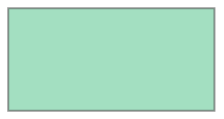

Map(center=[15, 45], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex…

In [2]:
from shapely.geometry import shape, Polygon
from pyproj import Transformer

if len(m.draw_features) == 0:
    raise RuntimeError("لم يتم رسم أي مضلع بعد — No polygon drawn yet. Run Cell 1 and draw a polygon first.")

# Take the most recently drawn feature
geojson_feature = m.draw_features[-1]
polygon = shape(geojson_feature['geometry'])
coords = list(polygon.exterior.coords)

print("إحداثيات Lat/Lon الأصلية (Original Lat/Lon coordinates):")
print(coords)

# Transform from WGS84 (EPSG:4326) to UTM Zone 38N (EPSG:32638)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32638", always_xy=True)
utm_coords = [transformer.transform(x, y) for x, y in coords]
utm_polygon = Polygon(utm_coords)

# Ensure counter-clockwise (CCW) winding order
if not utm_polygon.exterior.is_ccw:
    utm_coords = list(utm_polygon.exterior.coords)[::-1]
    utm_polygon = Polygon(utm_coords)

print("\nتم تحويل الإحداثيات إلى UTM وترتيبها CCW بنجاح")
print("(Coordinates transformed to UTM and ordered CCW successfully)")
print(f"\nUTM Coords ({len(utm_coords)} vertices):")
for i, c in enumerate(utm_coords):
    print(f"  [{i}] x={c[0]:.2f}, y={c[1]:.2f}")

from IPython.display import display
display(utm_polygon)  # Show the 2D polygon shape

# Create an interactive map for the extracted feature
m2 = leafmap.Map(center=[15, 45], zoom=16)
fc = {"type": "FeatureCollection", "features": [geojson_feature]}
m2.add_geojson(fc, layer_name="Extracted Polygon")
m2

---
## الخلية 3: إرسال الشكل إلى PyPRT وتوليد المبنى Procedural
## Cell 3: Send Shape to PyPRT & Generate Procedural Building

In [3]:
import pyprt, os, numpy as np, trimesh, json, base64

# ... (تأكد من وجود utm_polygon من الخلية 2) ...

pyprt.initialize_prt()
coords_2d = list(utm_polygon.exterior.coords)[:-1] 
flat_coords = []
for x, y in coords_2d: flat_coords.extend([x, 0.0, y]) 

initial_shape = pyprt.InitialShape(flat_coords)
attributes = {"Nbr_of_Floors": 12, "Usage": "Residential"} # مثال

RPK_PATH = r"C:\RPK\RuleFootprint.rpk"
model_generator = pyprt.ModelGenerator([initial_shape])
generated_models = model_generator.generate_model([attributes], RPK_PATH, "com.esri.pyprt.PyEncoder", {"emitGeometry": True})

if generated_models and generated_models[0]:
    gm = generated_models[0]
    raw_verts = np.array(gm.get_vertices(), dtype=np.float32).reshape(-1, 3)
    
    # 1. التوسيط لضمان الدقة
    center_point = np.mean(raw_verts, axis=0)
    centered_verts = raw_verts - center_point
    
    raw_indices, raw_faces = gm.get_indices(), gm.get_faces()
    triangles, face_colors, offset = [], [], 0
    
    for n in raw_faces:
        idx = raw_indices[offset:offset + n]
        # حساب الميل (Normal) لتحديد السطح من الجدران
        v1, v2, v3 = raw_verts[idx[0]], raw_verts[idx[1]], raw_verts[idx[2]]
        normal = np.cross(v2-v1, v3-v1)
        is_roof = normal[1] > 0.8 # إذا كان الاتجاه للأعلى فهو سطح
        
        color = [200, 200, 200, 255] if is_roof else [240, 230, 210, 255] # لون السطح رمادي والجدران كريمي
        
        for i in range(1, n - 1):
            triangles.append([idx[0], idx[i], idx[i + 1]])
            face_colors.append(color)
        offset += n

    # إنشاء مش المبنى مع الألوان
    mesh = trimesh.Trimesh(vertices=centered_verts, faces=triangles, face_colors=face_colors)
    
    # 2. إضافة "أرضية" تحت المبنى لإظهار الظلال والعمق
    floor = trimesh.creation.box(extents=[100, 0.1, 100]) # أرضية 100x100 متر
    floor.visual.face_colors = [50, 50, 50, 255] # لون غامق للأرضية
    
    # دمج المبنى مع الأرضية
    scene = trimesh.Scene([mesh, floor])
    
    # تصدير المشهد بالكامل كـ GLB
    glb_data = scene.export(file_type='glb')
    model_b64 = base64.b64encode(glb_data).decode('utf-8')
    
    print(f"✅ Model Ready with Colors and Floor Context.")


[PRT] [2026-03-11 23:57:26] [warning] CGB file contains warning 'Potentially problematic CGAC version 1.16 : major number smaller than current (2.10). Recompiling with current CGA Compiler is recommended.'
✅ Model Ready with Colors and Floor Context.


---
## الخلية 4: عرض النموذج باستخدام Autodesk Viewer
## Cell 4: Visualize the Model with Autodesk Viewer

In [8]:
from IPython.display import HTML, display

html_code = f"""
<div id='viewer-v14' style='width:100%; height:600px; background: linear-gradient(#202020, #444); border-radius:10px;'></div>
<div id='log-v14' style='color:#0f0; background:#000; padding:5px; font-family:monospace; font-size:11px;'>Initializing High-Quality Mode...</div>

<script src='https://developer.api.autodesk.com/modelderivative/v2/viewers/7.98/viewer3D.min.js'></script>
<script src='https://developer.api.autodesk.com/modelderivative/v2/viewers/7.98/extensions/glTF/glTF.min.js'></script>

<script>
(function() {{
    const log = (m) => document.getElementById('log-v14').innerText = '> ' + m;
    
    function b64ToBlob(b64) {{
        const bin = atob(b64);
        const buf = new Uint8Array(bin.length);
        for (let i = 0; i < bin.length; i++) buf[i] = bin.charCodeAt(i);
        return new Blob([buf], {{type: 'model/gltf-binary'}});
    }}

    function start() {{
        if (typeof Autodesk === 'undefined' || typeof Autodesk.Viewing.Extensions.glTF === 'undefined') {{
            setTimeout(start, 500); return;
        }}
        
        Autodesk.Viewing.Initializer({{ env: 'Local' }}, function() {{
            const viewer = new Autodesk.Viewing.GuiViewer3D(document.getElementById('viewer-v14'));
            viewer.start();
            
            // ضبط الإضاءة والبيئة
            viewer.setTheme('dark-theme');
            
            const url = URL.createObjectURL(b64ToBlob("{model_b64}"));
            viewer.loadModel(url + '#.glb', {{ fileExt: 'glb' }}, () => {{
                log('Model Loaded with Textures and Environmental Light.');
                
                // تفعيل إضاءة الشمس والبيئية لمنع اللون الأسود
                viewer.setLightPreset(4); // Urban Preset
                viewer.setEnvMapBackground(false);
                viewer.fitToView();
            }});
        }});
    }}
    start();
}})();
</script>
"""
display(HTML(html_code))
